Packages loaded successfully.
USGS output directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/usgs_landslides

Virginia boundary loaded successfully.
CRS: EPSG:4326
Bounds: [-83.67539511  36.5407366  -75.24245918  39.46601177]
Number of ScienceBase search results: 1
0 Preliminary Landslide Inventory for Landslides Triggered by Hurricane Helene (September 2024) 674634a1d34e6d1dac3abddc

Selected USGS ScienceBase item:
Preliminary Landslide Inventory for Landslides Triggered by Hurricane Helene (September 2024)

ScienceBase item ID:
674634a1d34e6d1dac3abddc

ScienceBase metadata saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/metadata/usgs_helene_landslide_sciencebase_metadata.json

Files available from the USGS record:
0 HurricaneHelene_LS_Inventory.zip https://www.sciencebase.gov/catalog/file/get/674634a1d34e6d1dac3abddc?f=__disk__94%2Faa%2F9c%2F94aa9c64c53ea49758d267f87994d36d2c14ca39
1 HurricaneHelene_LS_Inventory.

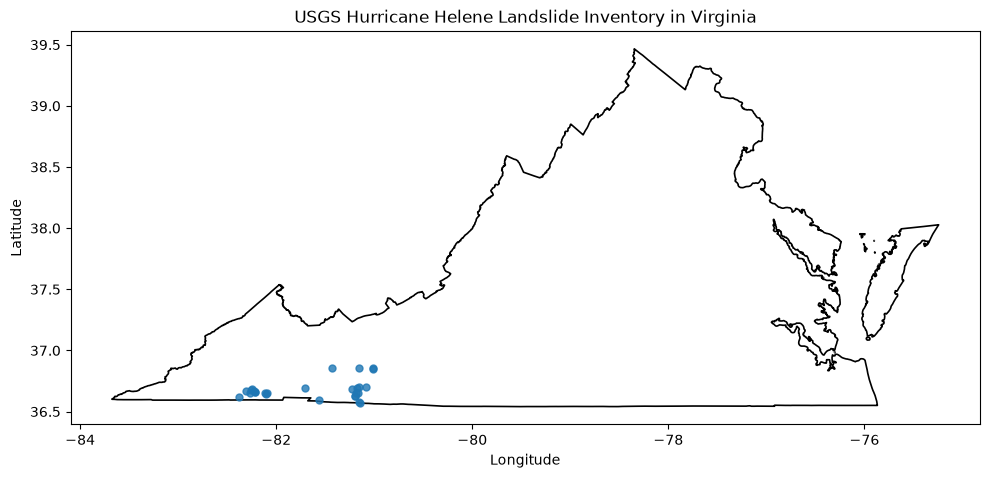


Map saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/usgs_landslides/helene_landslides_virginia_map.png

Dataset summary saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/metadata/usgs_helene_landslide_summary.csv

USGS file inventory saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/metadata/usgs_helene_file_inventory.csv

USGS HURRICANE HELENE LANDSLIDE DOWNLOAD SUMMARY
ScienceBase item ID: 674634a1d34e6d1dac3abddc
Complete inventory records: 2,217
Virginia inventory records: 27
Virginia GeoJSON exists: True
Virginia CSV exists: True

USGS output directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/usgs_landslides

Notebook completed successfully.


In [1]:
# =============================================================================
# 03_download_usgs.ipynb
#
# Purpose:
# Download the USGS Hurricane Helene landslide inventory,
# filter the inventory to Virginia, and save the resulting
# point dataset and metadata.
#
# Main output folder:
# /Users/gaoyujuan/REAP Dropbox/Gao yujuan/
# Virginia Tech/CALS/datasets/boundaries/usgs_landslides/
# =============================================================================


# =============================================================================
# 1. Load packages
# =============================================================================

from pathlib import Path
import shutil
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

print("Packages loaded successfully.")


# =============================================================================
# 2. Define project paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

BOUNDARIES_DIR = BASE_DIR / "boundaries"
METADATA_DIR = BASE_DIR / "metadata"

VIRGINIA_DIR = BOUNDARIES_DIR / "virginia"
USGS_DIR = BOUNDARIES_DIR / "usgs_landslides"

USGS_RAW_DIR = USGS_DIR / "raw"
USGS_COMPLETE_DIR = USGS_DIR / "complete"
USGS_VIRGINIA_DIR = USGS_DIR / "virginia"

for folder in [
    BOUNDARIES_DIR,
    METADATA_DIR,
    USGS_DIR,
    USGS_RAW_DIR,
    USGS_COMPLETE_DIR,
    USGS_VIRGINIA_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print("USGS output directory:")
print(USGS_DIR)


# =============================================================================
# 3. Define reusable helper functions
# =============================================================================

def download_file(
    url: str,
    output_path: Path,
    overwrite: bool = False,
    timeout: int = 180,
) -> Path:
    """
    Download a file and return its local path.
    """

    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if output_path.exists() and not overwrite:
        print(f"Already exists: {output_path}")
        return output_path

    print(f"\nDownloading:\n{url}")

    with requests.get(
        url,
        stream=True,
        timeout=timeout,
    ) as response:

        response.raise_for_status()

        with output_path.open("wb") as file:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):

                if chunk:
                    file.write(chunk)

    print(f"Saved to:\n{output_path}")

    return output_path


def unzip_file(
    zip_path: Path,
    output_directory: Path,
    overwrite: bool = False,
) -> Path:
    """
    Extract a ZIP archive and return the extraction folder.
    """

    zip_path = Path(zip_path)
    output_directory = Path(output_directory)

    if output_directory.exists() and overwrite:
        shutil.rmtree(output_directory)

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    with zipfile.ZipFile(
        zip_path,
        "r",
    ) as archive:

        archive.extractall(
            output_directory
        )

    print(f"Extracted to:\n{output_directory}")

    return output_directory


# =============================================================================
# 4. Load Virginia boundary
# =============================================================================

VIRGINIA_FILE = (
    VIRGINIA_DIR /
    "virginia_boundary.geojson"
)

if not VIRGINIA_FILE.exists():

    raise FileNotFoundError(
        "Virginia boundary file was not found.\n"
        "Run 01_download_virginia_boundary.ipynb first.\n\n"
        f"Expected file:\n{VIRGINIA_FILE}"
    )

virginia = gpd.read_file(
    VIRGINIA_FILE
)

if virginia.crs is None:

    virginia = virginia.set_crs(
        "EPSG:4326"
    )

else:

    virginia = virginia.to_crs(
        "EPSG:4326"
    )

print("\nVirginia boundary loaded successfully.")
print("CRS:", virginia.crs)
print("Bounds:", virginia.total_bounds)


# =============================================================================
# 5. Search USGS ScienceBase for the Helene landslide inventory
# =============================================================================

SCIENCEBASE_SEARCH_URL = (
    "https://www.sciencebase.gov/catalog/items"
)

search_parameters = {
    "format": "json",
    "q": (
        '"Preliminary Landslide Inventory" '
        '"Hurricane Helene"'
    ),
    "max": 50,
}

response = requests.get(
    SCIENCEBASE_SEARCH_URL,
    params=search_parameters,
    timeout=180,
)

response.raise_for_status()

search_results = response.json()

sciencebase_items = search_results.get(
    "items",
    [],
)

print(
    f"Number of ScienceBase search results: "
    f"{len(sciencebase_items)}"
)

for index, item in enumerate(
    sciencebase_items
):

    print(
        index,
        item.get("title"),
        item.get("id"),
    )


# =============================================================================
# 6. Select the correct USGS inventory record
# =============================================================================

matching_items = [
    item
    for item in sciencebase_items
    if "hurricane helene"
    in item.get("title", "").lower()
    and "landslide"
    in item.get("title", "").lower()
    and "inventory"
    in item.get("title", "").lower()
]

if not matching_items:

    raise RuntimeError(
        "The Hurricane Helene landslide inventory "
        "was not found in the USGS ScienceBase search."
    )

# Prefer a title containing "preliminary"
preliminary_matches = [
    item
    for item in matching_items
    if "preliminary"
    in item.get("title", "").lower()
]

if preliminary_matches:

    usgs_item = preliminary_matches[0]

else:

    usgs_item = matching_items[0]

USGS_ITEM_ID = usgs_item["id"]

print("\nSelected USGS ScienceBase item:")
print(usgs_item.get("title"))

print("\nScienceBase item ID:")
print(USGS_ITEM_ID)


# =============================================================================
# 7. Download and save the ScienceBase metadata
# =============================================================================

ITEM_METADATA_URL = (
    "https://www.sciencebase.gov/catalog/item/"
    f"{USGS_ITEM_ID}?format=json"
)

response = requests.get(
    ITEM_METADATA_URL,
    timeout=180,
)

response.raise_for_status()

usgs_metadata = response.json()

USGS_METADATA_JSON = (
    METADATA_DIR /
    "usgs_helene_landslide_sciencebase_metadata.json"
)

with USGS_METADATA_JSON.open(
    "w",
    encoding="utf-8",
) as file:

    import json

    json.dump(
        usgs_metadata,
        file,
        indent=2,
    )

print("\nScienceBase metadata saved to:")
print(USGS_METADATA_JSON)


# =============================================================================
# 8. List the files attached to the ScienceBase record
# =============================================================================

usgs_files = usgs_metadata.get(
    "files",
    [],
)

if not usgs_files:

    raise RuntimeError(
        "The selected ScienceBase record has no downloadable files."
    )

print("\nFiles available from the USGS record:")

for index, file_info in enumerate(
    usgs_files
):

    print(
        index,
        file_info.get("name"),
        file_info.get("url"),
    )


# =============================================================================
# 9. Identify the preferred spatial data file
#
# Preference order:
#   1. GeoJSON
#   2. Zipped shapefile
#   3. Geodatabase ZIP
#   4. CSV containing longitude and latitude
# =============================================================================

geojson_files = [
    file_info
    for file_info in usgs_files
    if file_info.get(
        "name",
        "",
    ).lower().endswith(
        ".geojson"
    )
]

shapefile_zip_files = [
    file_info
    for file_info in usgs_files
    if file_info.get(
        "name",
        "",
    ).lower().endswith(
        ".zip"
    )
    and (
        "shape"
        in file_info.get(
            "name",
            "",
        ).lower()
        or "shp"
        in file_info.get(
            "name",
            "",
        ).lower()
        or "inventory"
        in file_info.get(
            "name",
            "",
        ).lower()
    )
]

other_zip_files = [
    file_info
    for file_info in usgs_files
    if file_info.get(
        "name",
        "",
    ).lower().endswith(
        ".zip"
    )
]

csv_files = [
    file_info
    for file_info in usgs_files
    if file_info.get(
        "name",
        "",
    ).lower().endswith(
        ".csv"
    )
]

selected_file = None
selected_type = None

if geojson_files:

    selected_file = geojson_files[0]
    selected_type = "geojson"

elif shapefile_zip_files:

    selected_file = shapefile_zip_files[0]
    selected_type = "zip"

elif other_zip_files:

    selected_file = other_zip_files[0]
    selected_type = "zip"

elif csv_files:

    selected_file = csv_files[0]
    selected_type = "csv"

else:

    raise RuntimeError(
        "No GeoJSON, ZIP, or CSV spatial file "
        "was found in the USGS ScienceBase record."
    )

print("\nSelected data file:")
print(selected_file.get("name"))

print("\nSelected file type:")
print(selected_type)


# =============================================================================
# 10. Download the selected USGS data file
# =============================================================================

selected_file_name = selected_file.get(
    "name"
)

selected_file_url = selected_file.get(
    "url"
)

if not selected_file_name:

    raise RuntimeError(
        "The selected USGS file does not have a filename."
    )

if not selected_file_url:

    raise RuntimeError(
        "The selected USGS file does not have a download URL."
    )

selected_download_path = (
    USGS_RAW_DIR /
    selected_file_name
)

download_file(
    url=selected_file_url,
    output_path=selected_download_path,
    overwrite=False,
)


# =============================================================================
# 11. Read the USGS landslide inventory
# =============================================================================

landslides = None

if selected_type == "geojson":

    landslides = gpd.read_file(
        selected_download_path
    )


elif selected_type == "zip":

    extracted_directory = unzip_file(
        zip_path=selected_download_path,
        output_directory=(
            USGS_RAW_DIR /
            selected_download_path.stem
        ),
        overwrite=False,
    )

    shapefiles = sorted(
        extracted_directory.rglob(
            "*.shp"
        )
    )

    geopackages = sorted(
        extracted_directory.rglob(
            "*.gpkg"
        )
    )

    geodatabases = sorted(
        extracted_directory.rglob(
            "*.gdb"
        )
    )

    geojsons = sorted(
        extracted_directory.rglob(
            "*.geojson"
        )
    )

    if shapefiles:

        print("\nShapefiles found:")

        for file in shapefiles:
            print(file)

        landslides = gpd.read_file(
            shapefiles[0]
        )

    elif geopackages:

        print("\nGeoPackages found:")

        for file in geopackages:
            print(file)

        available_layers = gpd.list_layers(
            geopackages[0]
        )

        print("\nAvailable GeoPackage layers:")
        print(available_layers)

        landslides = gpd.read_file(
            geopackages[0],
            layer=available_layers.iloc[0]["name"],
        )

    elif geodatabases:

        print("\nFile geodatabases found:")

        for file in geodatabases:
            print(file)

        available_layers = gpd.list_layers(
            geodatabases[0]
        )

        print("\nAvailable geodatabase layers:")
        print(available_layers)

        landslides = gpd.read_file(
            geodatabases[0],
            layer=available_layers.iloc[0]["name"],
        )

    elif geojsons:

        landslides = gpd.read_file(
            geojsons[0]
        )

    else:

        raise FileNotFoundError(
            "The ZIP archive did not contain a readable "
            "shapefile, GeoPackage, geodatabase, or GeoJSON."
        )


elif selected_type == "csv":

    landslide_table = pd.read_csv(
        selected_download_path
    )

    print("\nCSV columns:")
    print(landslide_table.columns.tolist())

    longitude_candidates = [
        column
        for column in landslide_table.columns
        if column.lower()
        in {
            "longitude",
            "lon",
            "long",
            "x",
        }
    ]

    latitude_candidates = [
        column
        for column in landslide_table.columns
        if column.lower()
        in {
            "latitude",
            "lat",
            "y",
        }
    ]

    if not longitude_candidates or not latitude_candidates:

        raise ValueError(
            "The CSV was downloaded, but longitude and "
            "latitude columns could not be identified."
        )

    longitude_column = (
        longitude_candidates[0]
    )

    latitude_column = (
        latitude_candidates[0]
    )

    landslides = gpd.GeoDataFrame(
        landslide_table.copy(),
        geometry=gpd.points_from_xy(
            landslide_table[
                longitude_column
            ],
            landslide_table[
                latitude_column
            ],
        ),
        crs="EPSG:4326",
    )


if landslides is None:

    raise RuntimeError(
        "The landslide inventory could not be read."
    )

print("\nUSGS landslide inventory loaded successfully.")
print("Number of records:", len(landslides))
print("CRS:", landslides.crs)
print("Geometry types:", landslides.geom_type.unique())
print("Columns:", landslides.columns.tolist())


# =============================================================================
# 12. Standardize the coordinate reference system
# =============================================================================

if landslides.crs is None:

    print(
        "\nWarning: the landslide inventory has no CRS. "
        "Assigning EPSG:4326."
    )

    landslides = landslides.set_crs(
        "EPSG:4326"
    )

else:

    landslides = landslides.to_crs(
        "EPSG:4326"
    )

print("\nStandardized CRS:")
print(landslides.crs)


# =============================================================================
# 13. Remove records without valid geometry
# =============================================================================

initial_count = len(
    landslides
)

landslides = landslides.loc[
    landslides.geometry.notna()
].copy()

landslides = landslides.loc[
    ~landslides.geometry.is_empty
].copy()

landslides = landslides.reset_index(
    drop=True
)

removed_count = (
    initial_count -
    len(landslides)
)

print(
    f"\nRemoved {removed_count:,} records "
    "with missing or empty geometry."
)


# =============================================================================
# 14. Add a unique USGS landslide identifier
# =============================================================================

landslides["usgs_landslide_id"] = [
    f"helene_landslide_{index:05d}"
    for index in range(
        1,
        len(landslides) + 1,
    )
]

print("\nUnique landslide IDs created.")


# =============================================================================
# 15. Save the complete USGS inventory
# =============================================================================

COMPLETE_GEOJSON = (
    USGS_COMPLETE_DIR /
    "helene_landslides_complete.geojson"
)

COMPLETE_GEOPACKAGE = (
    USGS_COMPLETE_DIR /
    "helene_landslides_complete.gpkg"
)

landslides.to_file(
    COMPLETE_GEOJSON,
    driver="GeoJSON",
)

if COMPLETE_GEOPACKAGE.exists():
    COMPLETE_GEOPACKAGE.unlink()

landslides.to_file(
    COMPLETE_GEOPACKAGE,
    layer="helene_landslides",
    driver="GPKG",
)

print("\nComplete USGS inventory saved to:")
print(COMPLETE_GEOJSON)
print(COMPLETE_GEOPACKAGE)


# =============================================================================
# 16. Filter the landslide inventory to Virginia
# =============================================================================

landslides_virginia = gpd.sjoin(
    landslides,
    virginia[["geometry"]],
    how="inner",
    predicate="intersects",
)

landslides_virginia = (
    landslides_virginia
    .drop(
        columns=["index_right"],
        errors="ignore",
    )
    .drop_duplicates(
        subset=[
            "usgs_landslide_id"
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nNumber of Helene landslide observations "
    f"in Virginia: {len(landslides_virginia):,}"
)


# =============================================================================
# 17. Save Virginia landslide inventory
# =============================================================================

VIRGINIA_LANDSLIDE_GEOJSON = (
    USGS_VIRGINIA_DIR /
    "helene_landslides_virginia.geojson"
)

VIRGINIA_LANDSLIDE_GEOPACKAGE = (
    USGS_VIRGINIA_DIR /
    "helene_landslides_virginia.gpkg"
)

landslides_virginia.to_file(
    VIRGINIA_LANDSLIDE_GEOJSON,
    driver="GeoJSON",
)

if VIRGINIA_LANDSLIDE_GEOPACKAGE.exists():
    VIRGINIA_LANDSLIDE_GEOPACKAGE.unlink()

landslides_virginia.to_file(
    VIRGINIA_LANDSLIDE_GEOPACKAGE,
    layer="helene_landslides_virginia",
    driver="GPKG",
)

print("\nVirginia landslide inventory saved to:")
print(VIRGINIA_LANDSLIDE_GEOJSON)
print(VIRGINIA_LANDSLIDE_GEOPACKAGE)


# =============================================================================
# 18. Save a CSV version with longitude and latitude
# =============================================================================

virginia_csv = (
    landslides_virginia.copy()
)

virginia_csv[
    "longitude"
] = virginia_csv.geometry.x

virginia_csv[
    "latitude"
] = virginia_csv.geometry.y

virginia_csv = pd.DataFrame(
    virginia_csv.drop(
        columns="geometry"
    )
)

VIRGINIA_LANDSLIDE_CSV = (
    USGS_VIRGINIA_DIR /
    "helene_landslides_virginia.csv"
)

virginia_csv.to_csv(
    VIRGINIA_LANDSLIDE_CSV,
    index=False,
)

print("\nVirginia landslide CSV saved to:")
print(VIRGINIA_LANDSLIDE_CSV)


# =============================================================================
# 19. Inspect attribute values
# =============================================================================

print("\nVirginia landslide columns:")
print(
    landslides_virginia.columns.tolist()
)

for column in landslides_virginia.columns:

    if column == "geometry":
        continue

    unique_count = (
        landslides_virginia[
            column
        ].nunique(
            dropna=False
        )
    )

    if unique_count <= 20:

        print(
            "\n" + "-" * 70
        )

        print(
            f"Column: {column}"
        )

        print(
            landslides_virginia[
                column
            ].value_counts(
                dropna=False
            )
        )


# =============================================================================
# 20. Plot Virginia landslide inventory
# =============================================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

virginia.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2,
)

if not landslides_virginia.empty:

    landslides_virginia.plot(
        ax=ax,
        markersize=25,
        alpha=0.8,
    )

ax.set_title(
    "USGS Hurricane Helene Landslide Inventory in Virginia"
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

plt.tight_layout()

MAP_FILE = (
    USGS_DIR /
    "helene_landslides_virginia_map.png"
)

plt.savefig(
    MAP_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nMap saved to:")
print(MAP_FILE)


# =============================================================================
# 21. Create dataset summary
# =============================================================================

summary_records = [
    {
        "dataset": "USGS Hurricane Helene landslide inventory",
        "sciencebase_item_id": USGS_ITEM_ID,
        "complete_record_count": len(
            landslides
        ),
        "virginia_record_count": len(
            landslides_virginia
        ),
        "complete_geojson": str(
            COMPLETE_GEOJSON
        ),
        "virginia_geojson": str(
            VIRGINIA_LANDSLIDE_GEOJSON
        ),
        "source_file": str(
            selected_download_path
        ),
    }
]

summary = pd.DataFrame(
    summary_records
)

SUMMARY_FILE = (
    METADATA_DIR /
    "usgs_helene_landslide_summary.csv"
)

summary.to_csv(
    SUMMARY_FILE,
    index=False,
)

print("\nDataset summary saved to:")
print(SUMMARY_FILE)


# =============================================================================
# 22. Create USGS file inventory
# =============================================================================

inventory_records = []

for file in sorted(
    USGS_DIR.rglob("*")
):

    if file.is_file():

        inventory_records.append(
            {
                "file_name": file.name,
                "extension": file.suffix.lower(),
                "file_path": str(file),
                "file_size_bytes": file.stat().st_size,
            }
        )

file_inventory = pd.DataFrame(
    inventory_records
)

FILE_INVENTORY_PATH = (
    METADATA_DIR /
    "usgs_helene_file_inventory.csv"
)

file_inventory.to_csv(
    FILE_INVENTORY_PATH,
    index=False,
)

print("\nUSGS file inventory saved to:")
print(FILE_INVENTORY_PATH)


# =============================================================================
# 23. Final validation
# =============================================================================

print("\n" + "=" * 75)
print("USGS HURRICANE HELENE LANDSLIDE DOWNLOAD SUMMARY")
print("=" * 75)

print(
    f"ScienceBase item ID: "
    f"{USGS_ITEM_ID}"
)

print(
    f"Complete inventory records: "
    f"{len(landslides):,}"
)

print(
    f"Virginia inventory records: "
    f"{len(landslides_virginia):,}"
)

print(
    f"Virginia GeoJSON exists: "
    f"{VIRGINIA_LANDSLIDE_GEOJSON.exists()}"
)

print(
    f"Virginia CSV exists: "
    f"{VIRGINIA_LANDSLIDE_CSV.exists()}"
)

print("\nUSGS output directory:")
print(USGS_DIR)

print("\nNotebook completed successfully.")